In [1]:
import pandas as pd

df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
import sqlite3

conn = sqlite3.connect("medi_ai.db")

df.to_sql(
    "heart_disease_data",
    conn,
    if_exists="replace",
    index=False
)

1025

In [7]:
query = """
SELECT COUNT(*) AS Total_Patients
FROM heart_disease_data
"""

pd.read_sql(query, conn)

,Total_Patients
0,1025


In [9]:
query = """
SELECT
target,
COUNT(*) AS Patients
FROM heart_disease_data
GROUP BY target
"""

pd.read_sql(query, conn)

,target,Patients
0,0,499
1,1,526


In [11]:
query = """
SELECT
sex,
COUNT(*) AS Total
FROM heart_disease_data
GROUP BY sex
"""

pd.read_sql(query, conn)

,sex,Total
0,0,312
1,1,713


In [13]:
query = """
SELECT
ROUND(AVG(chol),2) AS Avg_Cholesterol
FROM heart_disease_data
"""

pd.read_sql(query, conn)

,Avg_Cholesterol
0,246.0


In [15]:
query = """
SELECT
ROUND(AVG(trestbps),2) AS Avg_BP
FROM heart_disease_data
"""

pd.read_sql(query, conn)

,Avg_BP
0,131.61


In [17]:
query = """
SELECT
cp,
COUNT(*) AS Patients
FROM heart_disease_data
GROUP BY cp
ORDER BY Patients DESC
"""

pd.read_sql(query, conn)

,cp,Patients
0,0,497
1,2,284
2,1,167
3,3,77


In [19]:
query = """
SELECT
target,
ROUND(AVG(age),2) AS Avg_Age
FROM heart_disease_data
GROUP BY target
"""

pd.read_sql(query, conn)

,target,Avg_Age
0,0,56.57
1,1,52.41


In [21]:
X = df.drop("target", axis=1)
y = df["target"]

print(X.shape)
print(y.shape)

(1025, 13)
(1025,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [25]:
y.value_counts()

target
1    526
0    499
Name: count, dtype: int64

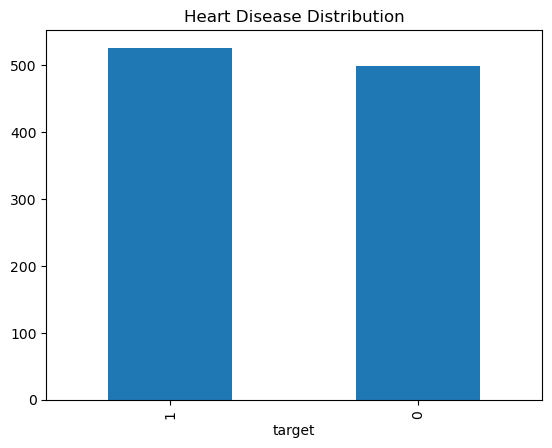

In [27]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.show()

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_score = lr.score(X_test, y_test)

print("Logistic Regression Accuracy:", lr_score)

Logistic Regression Accuracy: 0.7951219512195122


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_score = rf.score(X_test, y_test)

print("Random Forest Accuracy:", rf_score)

Random Forest Accuracy: 0.9853658536585366


In [33]:
print("Logistic Regression:", lr_score)
print("Random Forest:", rf_score)

Logistic Regression: 0.7951219512195122
Random Forest: 0.9853658536585366


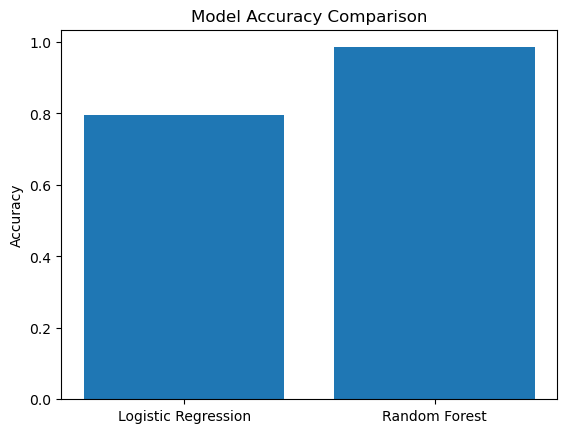

In [35]:
models = ["Logistic Regression", "Random Forest"]
scores = [lr_score, rf_score]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [37]:
from sklearn.metrics import confusion_matrix

pred = rf.predict(X_test)

cm = confusion_matrix(y_test, pred)

print(cm)

[[102   0]
 [  3 100]]


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [41]:
import pickle

pickle.dump(
    rf,
    open("medi_ai_model.pkl", "wb")
)

In [43]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

probability = rf.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.97 0.03]]


In [45]:
predictions = rf.predict(X)

probabilities = rf.predict_proba(X)

In [47]:
results = df.copy()

results["Prediction"] = predictions

results["Confidence"] = probabilities.max(axis=1) * 100

In [49]:
results["Risk Level"] = results["Prediction"].map(
    {
        0: "High Risk",
        1: "Low Risk"
    }
)

In [51]:
results.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Prediction,Confidence,Risk Level
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0,97.0,High Risk
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0,100.0,High Risk
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0,100.0,High Risk
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0,97.0,High Risk
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0,96.0,High Risk


In [53]:
results.to_csv(
    "patient_predictions.csv",
    index=False
)

In [55]:
results["Age Group"] = pd.cut(
    results["age"],
    bins=[0,30,40,50,60,100],
    labels=[
        "Under 30",
        "30-40",
        "40-50",
        "50-60",
        "60+"
    ]
)

In [57]:
results["Gender"] = results["sex"].map(
    {
        0:"Female",
        1:"Male"
    }
)

In [59]:
results["Chest Pain Type"] = results["cp"].map(
{
0:"Typical Angina",
1:"Atypical Angina",
2:"Non-Anginal Pain",
3:"Asymptomatic"
}
)

In [61]:
results.to_csv(
    "medi_ai_final.csv",
    index=False
)